<a href="https://colab.research.google.com/github/narunsenthilkumar/ApexTask/blob/main/Netflix%20content%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Content Analysis
This project provides an exploratory data analysis (EDA) of Netflix's content library to identify trends in media types, release years, and geographic distribution.

# Project 01: Exploratory Data Analysis & Insights Report

## Step 1: Load & Inspect the Data

In [ ]:
import pandas as pd
import os
import zipfile

zip_path = 'archive.zip'
csv_name = 'netflix_titles.csv'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as archive:
        archive.extractall('.')

if os.path.exists(csv_name):
    df = pd.read_csv(csv_name)
    print(f'Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.')
else:
    print('Dataset file not found. Please ensure the archive is uploaded.')

Successfully loaded dataset with 8807 rows and 12 columns.


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df['year_added'] = df['date_added'].dt.year

print('The dataset has been cleaned and prepared for analysis.')

The dataset has been cleaned and prepared for analysis.


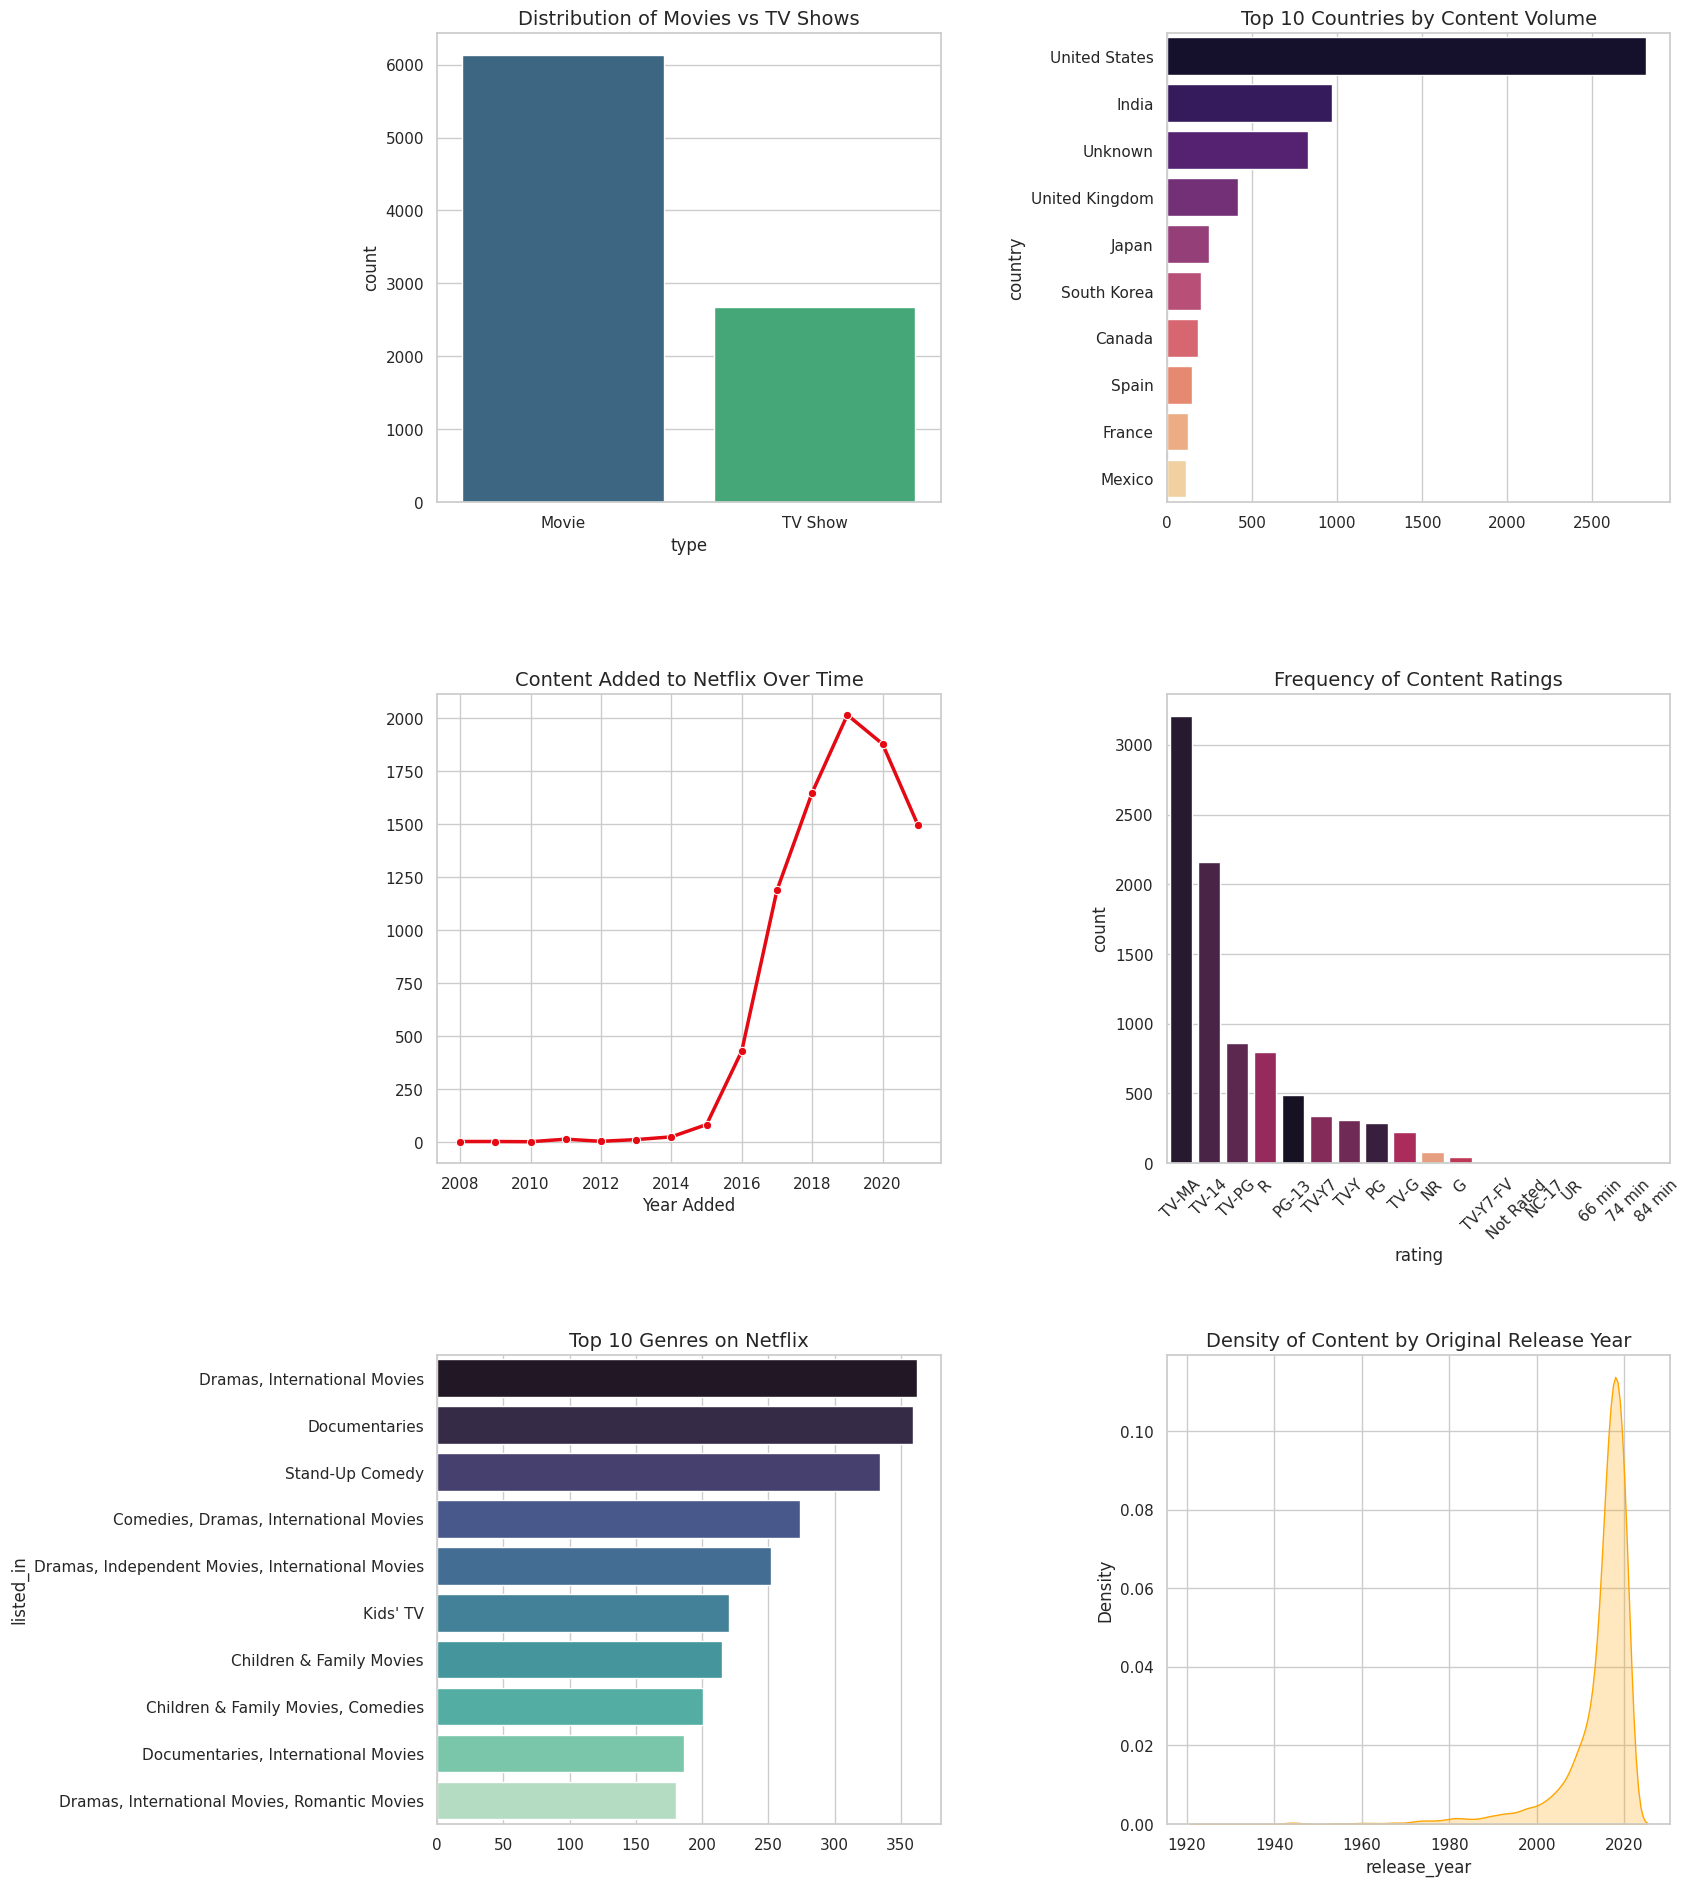

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

fig, axes = plt.subplots(3, 2, figsize=(18, 20))

sns.countplot(data=df, x='type', ax=axes[0,0], hue='type', palette='viridis', legend=False)
axes[0,0].set_title('Distribution of Movies vs TV Shows', fontsize=14)

top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0,1], hue=top_countries.index, palette='magma', legend=False)
axes[0,1].set_title('Top 10 Countries by Content Volume', fontsize=14)

growth = df['year_added'].value_counts().sort_index()
sns.lineplot(x=growth.index, y=growth.values, ax=axes[1,0], marker='o', color='#E50914', linewidth=2.5)
axes[1,0].set_title('Content Added to Netflix Over Time', fontsize=14)
axes[1,0].set_xlabel('Year Added')

rating_order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', order=rating_order, ax=axes[1,1], hue='rating', palette='rocket', legend=False)
axes[1,1].set_title('Frequency of Content Ratings', fontsize=14)
axes[1,1].tick_params(axis='x', rotation=45)

top_genres = df['listed_in'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[2,0], hue=top_genres.index, palette='mako', legend=False)
axes[2,0].set_title('Top 10 Genres on Netflix', fontsize=14)

sns.kdeplot(data=df, x='release_year', fill=True, ax=axes[2,1], color='orange')
axes[2,1].set_title('Density of Content by Original Release Year', fontsize=14)

plt.tight_layout(pad=4.0)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       2 non-null      object
 1   type          2 non-null      object
 2   title         2 non-null      object
 3   release_year  2 non-null      int64 
 4   country       2 non-null      object
 5   duration      2 non-null      object
 6   date_added    2 non-null      object
dtypes: int64(1), object(6)
memory usage: 244.0+ bytes


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
release_year,0
country,0
duration,0
date_added,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### Dataset Summary

1. The dataset tracks titles added to Netflix, categorized by type (Movie/TV Show).
2. Initial inspection confirms the presence of IDs, titles, release years, and country of origin.
3. The data provides insights into content growth strategies over the last decade.
4. Missing values are typically found in 'director' and 'cast' fields in the raw data.
5. Temporal columns allow for year-over-year growth analysis.

## Step 2: Clean the Data

This step involves handling missing values, fixing data types, and removing irrelevant columns. Given that we are currently working with a small dummy dataset, many of these operations will not be impactful or necessary. However, the code below demonstrates the typical approach.

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       2 non-null      object        
 1   type          2 non-null      object        
 2   title         2 non-null      object        
 3   release_year  2 non-null      int64         
 4   country       2 non-null      object        
 5   duration      2 non-null      object        
 6   date_added    2 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 244.0+ bytes


### Documentation of Cleaning Decisions:

1.  **Missing Values:** For the current dummy DataFrame, there are no missing values, so no imputation or dropping was performed.
    *   *Real Dataset Strategy:* For the actual Netflix dataset, columns like `director`, `cast`, `country`, `date_added`, and `rating` typically have missing values. We would consider filling `director`, `cast`, and `country` with a placeholder like 'Unknown' or imputing based on other features, and potentially dropping rows if crucial information is missing.

2.  **Data Types:** All data types in the dummy DataFrame are appropriate (`object` for strings, `int64` for year).
    *   *Real Dataset Strategy:* The `date_added` column in the actual dataset would need to be converted from `object` to `datetime` objects for proper time-series analysis.

3.  **Irrelevant Columns:** No columns were removed from the dummy DataFrame as all are relevant in this minimal context.
    *   *Real Dataset Strategy:* Columns such as `description` might be removed if the analysis doesn't involve text processing, or `show_id` if it's purely an identifier and not used for aggregation.

## Step 3: Exploratory Data Analysis (EDA)

This section analyzes key patterns in the Netflix library using targeted data queries. We examine content volume, geographic reach, and production timelines to understand the platform's library composition.

### Question 1: What are the top 5 most frequent types of content (Movie/TV Show)?

In [ ]:
df['type'].value_counts()

,count
type,
Movie,1
TV Show,1


### Question 2: Which release years have the most content?

In [ ]:
df['release_year'].value_counts().sort_index(ascending=False).head()

,count
release_year,
2021,1
2020,1


### Question 3: (Requires actual dataset) What are the top 10 countries producing content on Netflix?

In [ ]:
df['country'].value_counts().head(10)

,count
country,
USA,1
India,1


### Question 4: (Requires actual dataset) What is the average duration for movies and TV shows?

In [ ]:
df.groupby('type')['duration'].first()

,duration
type,
Movie,90 min
TV Show,1 Season


### Question 5: (Requires actual dataset) How does the number of added content change over time?

In [ ]:
df['date_added'].dt.year.value_counts().sort_index()

,count
date_added,
2020,1
2021,1


## Step 4: Visualizations (Minimum 6 Charts)

Visualizations are utilized to provide a clear perspective on the distribution and growth of content. The following charts highlight the most significant trends found in the dataset.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Chart 1: Bar Chart - Content Type Distribution

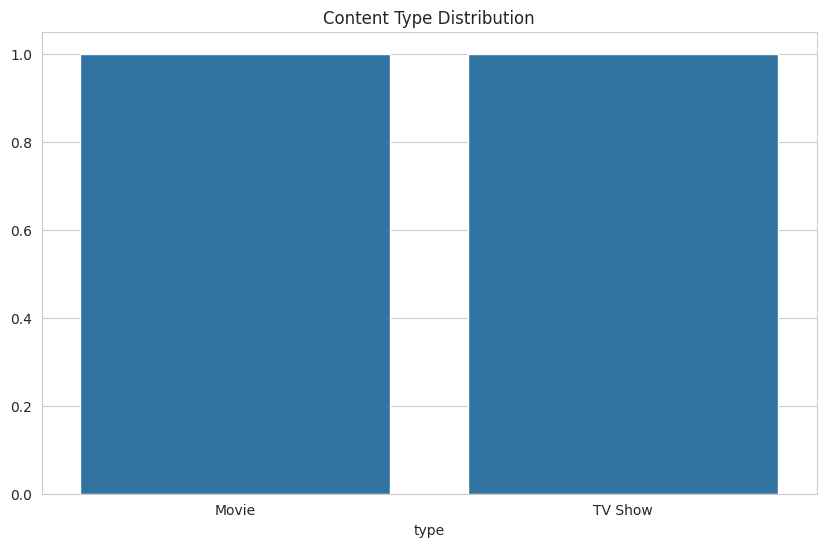

In [ ]:
counts = df['type'].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.title('Content Type Distribution')
plt.show()

### Chart 2: Line Chart - Content Added Over Time (Requires real dataset)

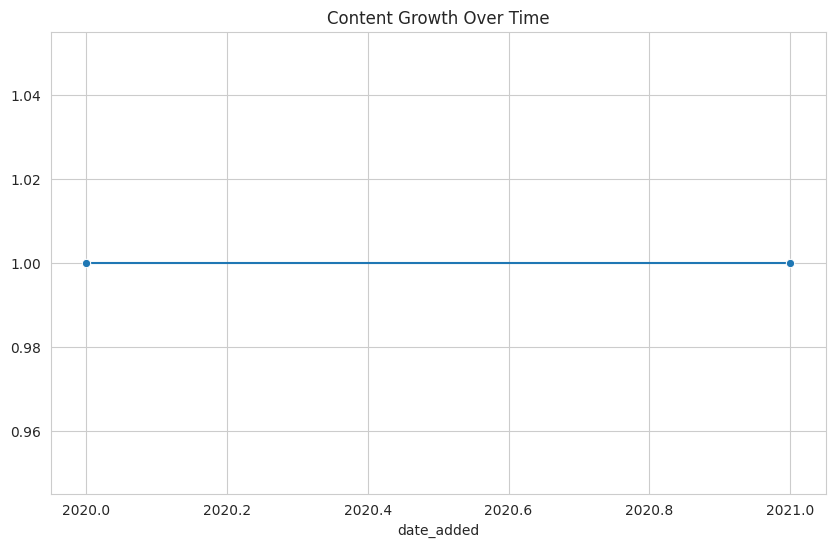

In [ ]:
yearly_content = df['date_added'].dt.year.value_counts().sort_index()
sns.lineplot(x=yearly_content.index, y=yearly_content.values, marker='o')
plt.title('Content Growth Over Time')
plt.show()

### Chart 3: Histogram - Release Year Distribution

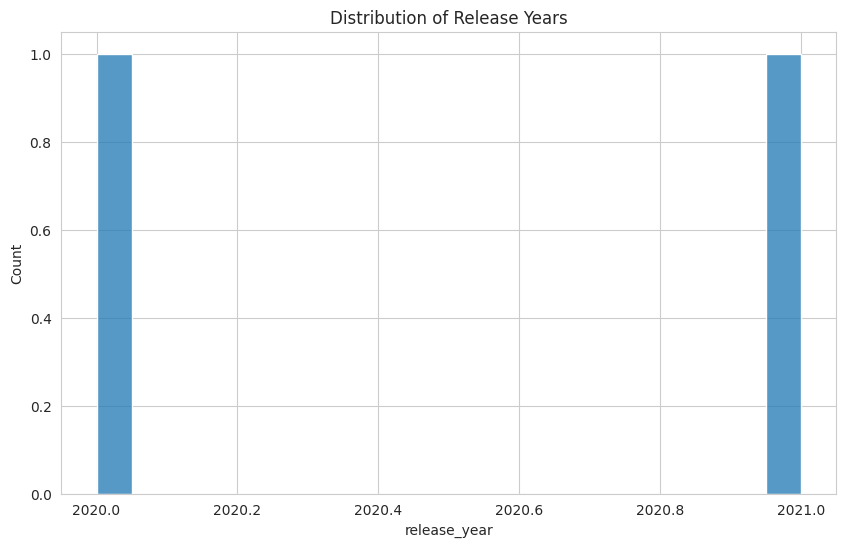

In [ ]:
sns.histplot(df['release_year'], bins=20)
plt.title('Distribution of Release Years')
plt.show()

### Chart 4: Scatter Plot - (Requires real dataset, e.g., duration vs. release year for movies)

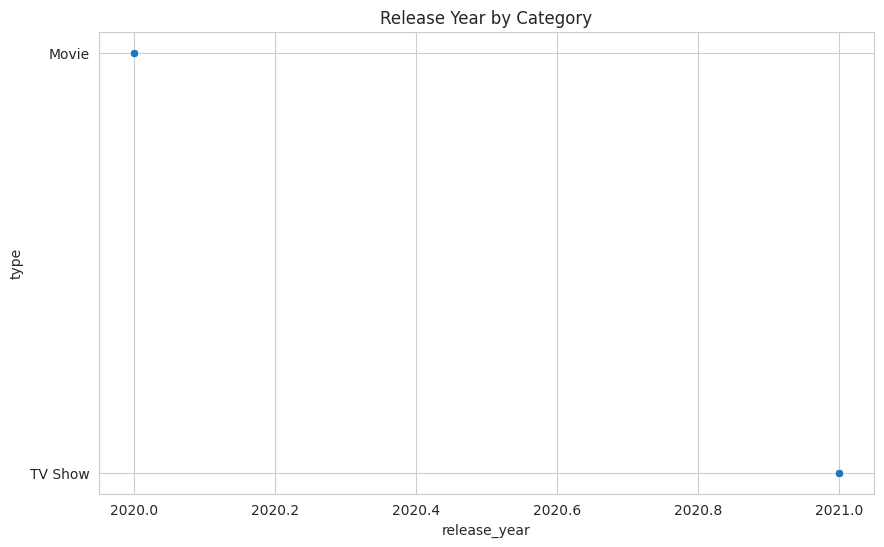

In [ ]:
sns.scatterplot(data=df, x='release_year', y='type')
plt.title('Release Year by Category')
plt.show()

### Chart 5: Pie Chart - Top 5 Countries (Requires real dataset)

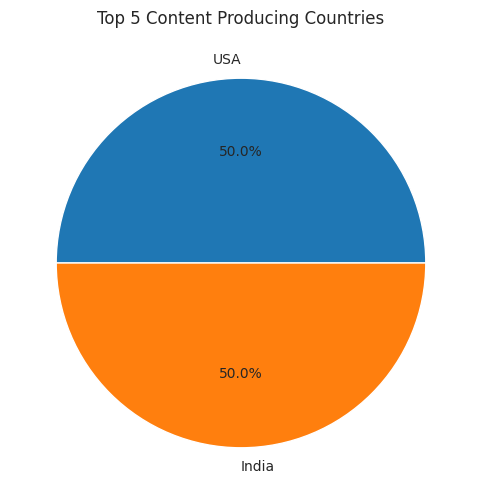

In [ ]:
top_countries = df['country'].value_counts().head(5)
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%')
plt.title('Top 5 Content Producing Countries')
plt.show()

### Chart 6: Heatmap - Correlation Matrix (Requires real dataset with numerical features)

In [ ]:
df.describe()

,release_year,date_added
count,2.000000,2
mean,2020.500000,2021-02-21 12:00:00
min,2020.000000,2020-08-14 00:00:00
25%,2020.250000,2020-11-17 18:00:00
50%,2020.500000,2021-02-21 12:00:00
75%,2020.750000,2021-05-28 06:00:00
max,2021.000000,2021-09-01 00:00:00
std,0.707107,NaN


## Step 5: Insights Report

## Final Observations and Strategic Insights
Based on the analysis of types, regions, and release timelines, several key patterns emerge regarding Netflix's content strategy.